## Import the Model

In [7]:
import sys
sys.path.append('../')

# import src.TagModel as model
# import src.TagModel_lat as model_latency
import src.Auth as Auth
import utils.utils as utils
import numpy as np
import matplotlib.pyplot as plt 
import json
import os
import threading

### Run the Model

Just considering the E[A]

In [ ]:
m_nrs = [20,30]
t_nrs = [5,10,15]
p = [.95, .9, .85, .8, .75, .7]
q = [1]


def run_optimize(parameters):
    os.system("python3 optimize.py \'"+json.dumps(parameters)+"\'")

threads = []
for m_nr in m_nrs:
    for t_nr in t_nrs:
        for p_ in p:
            for q_ in q:
                parameters = {'m_nr': m_nr, 't_nr': t_nr, 
                              'p': p_, 'q': q_, 
                              'TagEveryMessage': True, 
                              'AtLeastOnce': False, 
                              'EquivalentA': True}
                threads.append(threading.Thread(target=run_optimize, args=(parameters,)))
                threads[-1].start() 
        cnt = 0
        for thread in threads:
            thread.join()
            cnt += 1
            print(cnt)
            
                # exp = utils.Run_Experiment(model        = model.math_model,
                #                            parameters   = parameters,
                #                            eval         = Auth.evaluate,
                #                            m_size       = 128,
                #                            t_size       = 256,
                #                            save         = True)


# parameters = {'m_nr': 25, 't_nr': 25, 
#               'p': 0.95, 'q': 1, 
#               'TagEveryMessage': True, 
#               'AtLeastOnce': False, 
#               'EquivalentA': True}

# exp = utils.Run_Experiment(model        = model.math_model,
#                            parameters   = parameters,
#                            eval         = Auth.evaluate,
#                            m_size       = 1024,
#                            t_size       = 256,
#                            save         = True)
# exp['eval']




### Looking at the saved Models

In [14]:
exp = utils.Load_Experiments()

import seaborn as sns

for i in exp:
    
    print(exp[i]['parameters'])
    # print(exp[i]['eval'])
    # sns.heatmap(exp[i]['results']['X'])
    # plt.show()
    # print('\n\n')

{'m_nr': 20, 't_nr': 5, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{

Golomb (g=1) valid? True differences: {1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1}


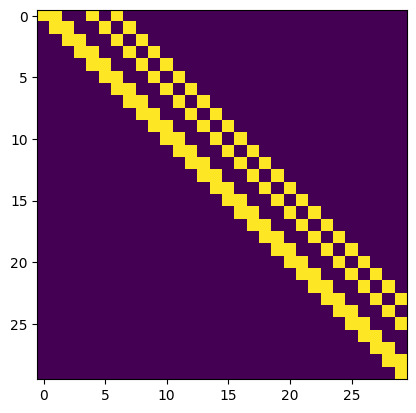

A_golomb shape: (30, 30)
g-Sidon (g=2) valid? True differences: {1: 1, 2: 1, 3: 1, 4: 2, 5: 1, 6: 2, 9: 1, 10: 1}
A_gsidon shape: (30, 30)
Greedy g-Sidon set (k=5, g=2): [0, 1, 2, 4, 7] valid? True


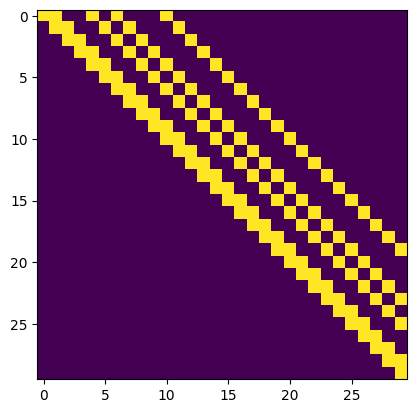

In [18]:
# -------------------------------
# Incidence matrices for Golomb (g=1) and g-Sidon sets
# -------------------------------
from collections import Counter
import numpy as np

def is_g_sidon(S, g=1):
    """
    Check whether a sorted set S (with S[0] == 0) is a g-Sidon set:
    every positive difference appears at most g times.
    Returns (True/False, difference_counts_dict).
    """
    S = sorted(S)
    diffs = [S[j] - S[i] for i in range(len(S)) for j in range(i+1, len(S))]
    c = Counter(d for d in diffs if d > 0)
    return (max(c.values(), default=0) <= g), dict(sorted(c.items()))

def build_incidence(N, S):
    """
    Build an N x N 0/1 incidence matrix A where A[i,j] = 1
    iff j - i is in S and indices are in range.
    Rows = messages i, Columns = tags j.
    """
    S = set(S)
    A = np.zeros((N, N), dtype=int)
    for j in range(N):
        for d in S:
            i = j - d
            if 0 <= i < N:
                A[i, j] = 1
    return A

def greedy_g_sidon(k, g=1, max_span=100):
    """
    Very simple greedy builder for a size-k g-Sidon set starting at 0.
    Tries to keep the span small (<= max_span).
    Not guaranteed optimal, but works well for small k.
    """
    S = [0]
    diff_counts = Counter()
    while len(S) < k:
        placed = False
        for cand in range(S[-1] + 1, max_span + 1):
            # Check if adding 'cand' keeps all differences <= g
            ok = True
            new_diffs = []
            for s in S:
                d = abs(cand - s)
                if d == 0:
                    ok = False
                    break
                new_diffs.append(d)
            if not ok:
                continue
            # Tentatively update counts
            tmp = diff_counts.copy()
            for d in new_diffs:
                tmp[d] += 1
                if tmp[d] > g:
                    ok = False
                    break
            if ok:
                S.append(cand)
                diff_counts = tmp
                placed = True
                break
        if not placed:
            raise ValueError("Failed to place next mark with given constraints; try increasing max_span.")
    return S

# -------------------------------
# EXAMPLES
# -------------------------------
if __name__ == "__main__":
    N = 30

    # 1) Golomb ruler example (g = 1)
    S_golomb = [0, 1, 4, 6]                    # classic 4-mark Golomb ruler
    ok1, counts1 = is_g_sidon(S_golomb, g=1)
    print("Golomb (g=1) valid?", ok1, "differences:", counts1)
    A_golomb = build_incidence(N, S_golomb)
    plt.imshow(A_golomb)
    plt.show()
    print("A_golomb shape:", A_golomb.shape)

    # 2) g-Sidon example (g ≈ 2). You can choose any set you like:
    S_gsidon = [0, 1, 4, 6, 10]                 # simple g=2 example
    ok2, counts2 = is_g_sidon(S_gsidon, g=2)
    print("g-Sidon (g=2) valid?", ok2, "differences:", counts2)
    A_gsidon = build_incidence(N, S_gsidon)
    plt.imshow(A_gsidon)

    print("A_gsidon shape:", A_gsidon.shape)

    # 3) (Optional) Build a g-Sidon set greedily: k marks, allowance g
    k = 5
    S_auto = greedy_g_sidon(k=k, g=2, max_span=60)
    oka, countsa = is_g_sidon(S_auto, g=2)
    print(f"Greedy g-Sidon set (k={k}, g=2):", S_auto, "valid?", oka)
    A_auto = build_incidence(N, S_auto)


### Creating a  progressive MAC for comparison

In [19]:
plot = False

### AGG MAC x ###
def AGG_MAC_x(m_nr, x):
    X = np.zeros((m_nr, m_nr//x))
    for i in range(m_nr):
        X[i, i//x] = 1
    return X


for x in [2,3,4,5]:
    X = AGG_MAC_x(35-35%x,x)

    for i in [.6,.7, .8 , .9]:
        parameters = {'m_nr': X.shape[0], 't_nr': X.shape[1],
                        'p': i, 'q': 1,
                        'x': x,
                        'name': f'AggMAC_{x}'}
        exp = Auth.Create_Experiment(parameters,X= X)
        exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
        if utils.Save_Experiment(exp) != True:
            print("Error saving experiment AggMAC" , "with parameters", parameters)

print("AGG MAC experiments done")

X = A_golomb
for i in [.6,.7, .8 , .9]:
    parameters = {'m_nr': X.shape[0], 't_nr': X.shape[1],
                    'p': i, 'q': 1,
                    'name': f'Golomb'}
    exp = Auth.Create_Experiment(parameters,X= X)
    exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
    if utils.Save_Experiment(exp) != True:
        print("Error saving experiment Golomb" , "with parameters", parameters) 

X = A_gsidon
for i in [.6,.7, .8 , .9]:
    parameters = {'m_nr': X.shape[0], 't_nr': X.shape[1],
                    'p': i, 'q': 1,
                    'name': f'g-Sidon_{2}'}
    exp = Auth.Create_Experiment(parameters,X= X)
    exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
    if utils.Save_Experiment(exp) != True:
        print("Error saving experiment g-Sidon" , "with parameters", parameters) 


for i in [.7, .8 , .9]:
    parameters = {'m_nr': 20, 't_nr': 20,
                    'p': i, 'q': 1, 
                    'name': 'trad'}

    exp = Auth.Create_Experiment(parameters,X= np.eye(parameters['m_nr']))
    exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256, security_requirments=256, plot=plot)
    if utils.Save_Experiment(exp) != True:
        print("Error saving experiment trad" , "with parameters", parameters)

    print("Traditional MAC experiments done")

    for x in [2,3,4,5]:

        parameters = {'m_nr': 20, 't_nr': 20,
                        'p': i, 'q': 1,
                        'x': x,
                        'name': f'Whip_{x}'}
        X = Auth.ProMAC_X(parameters['m_nr'],parameters['x'])
        exp = Auth.Create_Experiment(parameters,X= X)
        exp['eval'] = Auth.evaluate(exp,m_size=1024,t_size=256/parameters['x'], security_requirments=256, plot=plot)
        if utils.Save_Experiment(exp) != True:
            print("Error saving experiment ProMAC" , "with parameters", parameters)

Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment with the same parameters already exist as experiment number 107
Error saving experiment AggMAC with parameters {'m_nr': 34, 't_nr': 17, 'p': 0.6, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment with the same parameters already exist as experiment number 36
Error saving experiment AggMAC with parameters {'m_nr': 34, 't_nr': 17, 'p': 0.7, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment with the same parameters already exist as experiment number 37
Error saving experiment AggMAC with parameters {'m_nr': 34, 't_nr': 17, 'p': 0.8, 'q': 1, 'x': 2, 'name': 'AggMAC_2'}
Status: 1
Objective value: 17.0
Status: 1
Objective value: 17.0
Experiment with the same parameters already exist as experiment number 38
Error saving experiment AggMAC with parameters {'m_nr': 34, 't_nr': 17, 'p': 0.9, 'q': 1, 'x'

In [6]:
experiments = utils.Load_Experiments()
for exp in experiments:
    print(experiments[exp]['parameters'])
    # print(experiments[exp]['eval'])
    # plt.imshow(experiments[exp]['results']['X'])
    # plt.show()
    # print('\n\n')



{'m_nr': 20, 't_nr': 5, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.8, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.7, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 5, 'p': 0.9, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.95, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.75, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{'m_nr': 20, 't_nr': 10, 'p': 0.85, 'q': 1, 'TagEveryMessage': True, 'AtLeastOnce': False, 'EquivalentA': True}
{

### Run the optimizer With Latency

In [ ]:
parameters = {'m_nr': 10, 't_nr': 10,
                'p': 0.9, 'q': .9,
                'TagEveryMessage': True,
                'AtLeastOnce': False,
                'EquivalentA': True,
                'weight_A': 1,
                'weight_L': 0}


for i in range(10):
    exp = utils.Run_Experiment(model = model_latency.math_model,
                            parameters = parameters,
                            eval=Auth.evaluate,
                            save=True,
                            m_size=1024,
                            t_size=256)
    parameters['weight_L'] += 0.1
    print(exp['eval'])

# exp['eval']